In [34]:
# ==========================================
# Sprint 5 - Feature Validation
# ==========================================


In [50]:
import pandas as pd 
import numpy as np 

import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import mutual_info_regression

In [51]:
pd.set_option("display.max_columns",None)

In [52]:
df = pd.read_csv("../data/interim/featured_ford.csv")

In [53]:
print("Shape:" , df.shape)
df.info()

Shape: (17966, 15)
<class 'pandas.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   model             17966 non-null  str    
 1   year              17966 non-null  int64  
 2   price             17966 non-null  int64  
 3   transmission      17966 non-null  str    
 4   mileage           17966 non-null  int64  
 5   fuelType          17966 non-null  str    
 6   tax               17966 non-null  int64  
 7   mpg               17966 non-null  float64
 8   engineSize        17966 non-null  float64
 9   car_age           17966 non-null  int64  
 10  mileage_per_year  17966 non-null  float64
 11  engine_category   17966 non-null  str    
 12  fuel_efficiency   17966 non-null  str    
 13  tax_category      17966 non-null  str    
 14  price_segment     17966 non-null  str    
dtypes: float64(3), int64(5), str(7)
memory usage: 2.1 MB


In [54]:
numeric_df = df.select_dtypes(include=np.number)

numeric_df.head()

,year,price,mileage,tax,mpg,engineSize,car_age,mileage_per_year
0,2017,12000,15944,150,57.7,1.0,9,1594.400000
1,2018,14000,9083,150,57.7,1.0,8,1009.222222
2,2017,13000,12456,150,57.7,1.0,9,1245.600000
3,2019,17500,10460,145,40.3,1.5,7,1307.500000
4,2019,16500,1482,145,48.7,1.0,7,185.250000


In [55]:
correlation_matrix = numeric_df.corr()

correlation_matrix

,year,price,mileage,tax,mpg,engineSize,car_age,mileage_per_year
year,1.000000,0.636009,-0.707818,0.298506,-0.022967,-0.137311,-1.000000,-0.532528
price,0.636009,1.000000,-0.530659,0.406857,-0.346419,0.411178,-0.636009,-0.461095
mileage,-0.707818,-0.530659,1.000000,-0.260451,0.120075,0.215035,0.707818,0.952875
tax,0.298506,0.406857,-0.260451,1.000000,-0.502980,0.184363,-0.298506,-0.266141
mpg,-0.022967,-0.346419,0.120075,-0.502980,1.000000,-0.260521,0.022967,0.183514
engineSize,-0.137311,0.411178,0.215035,0.184363,-0.260521,1.000000,0.137311,0.210470
car_age,-1.000000,-0.636009,0.707818,-0.298506,0.022967,0.137311,1.000000,0.532528
mileage_per_year,-0.532528,-0.461095,0.952875,-0.266141,0.183514,0.210470,0.532528,1.000000


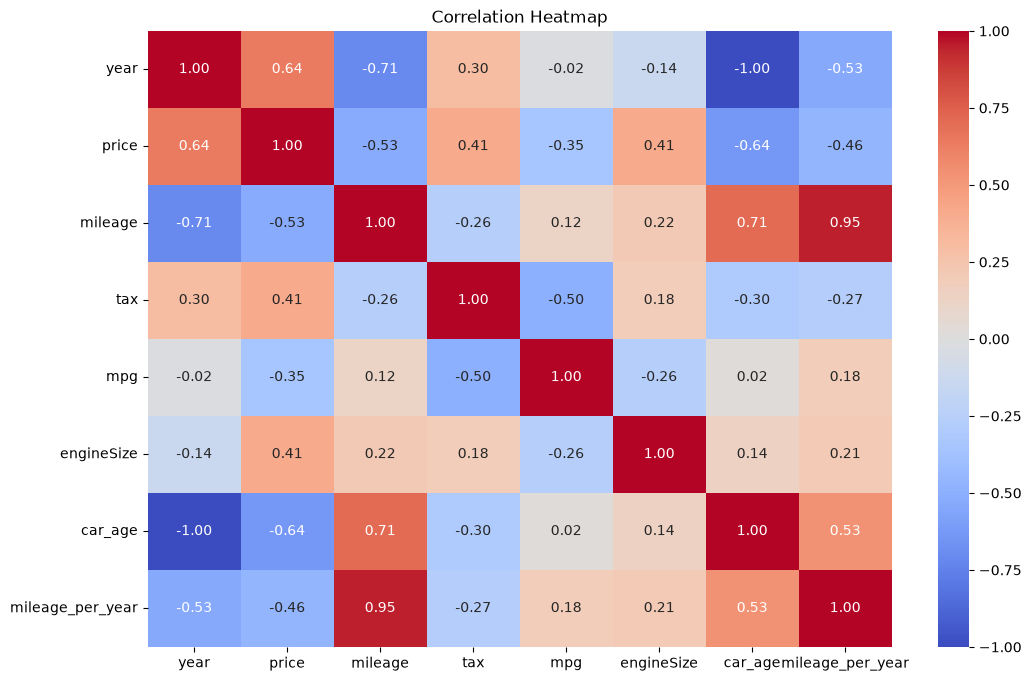

In [56]:
plt.figure(figsize=(12,8))

sns.heatmap(
    correlation_matrix,
    annot = True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [57]:
price_corr = correlation_matrix["price"].sort_values(ascending=False)

In [58]:
price_corr

price               1.000000
year                0.636009
engineSize          0.411178
tax                 0.406857
mpg                -0.346419
mileage_per_year   -0.461095
mileage            -0.530659
car_age            -0.636009
Name: price, dtype: float64

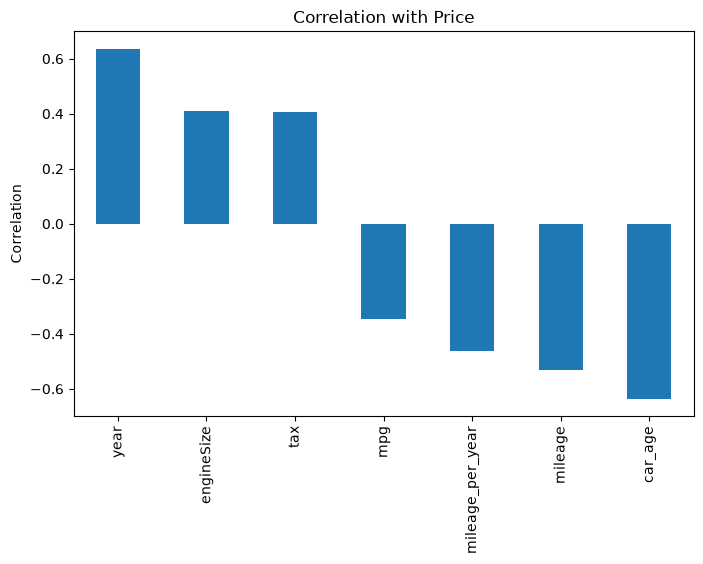

In [59]:
plt.figure(figsize=(8,5))

price_corr.drop("price").plot(kind="bar")

plt.title("Correlation with Price")

plt.ylabel("Correlation")

plt.show()

In [60]:
X= df.drop(columns=["price"])
y= df["price"]

In [61]:
X_encoded = pd.get_dummies(X,drop_first=True)

In [62]:
X_encoded.head()

,year,mileage,tax,mpg,engineSize,car_age,mileage_per_year,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,model_ Fiesta,model_ Focus,model_ Fusion,model_ Galaxy,model_ Grand C-MAX,model_ Grand Tourneo Connect,model_ KA,model_ Ka+,model_ Kuga,model_ Mondeo,model_ Mustang,model_ Puma,model_ Ranger,model_ S-MAX,model_ Streetka,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol,engine_category_medium,engine_category_small,fuel_efficiency_low,fuel_efficiency_medium,tax_category_low,tax_category_medium,price_segment_Economy,price_segment_Luxury,price_segment_Premium
0,2017,15944,150,57.7,1.0,9,1594.400000,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,True,False,True,False,False,True
1,2018,9083,150,57.7,1.0,8,1009.222222,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,True,False,True,False,True,False,False,True
2,2017,12456,150,57.7,1.0,9,1245.600000,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,True,False,True,False,True,False,False,True
3,2019,10460,145,40.3,1.5,7,1307.500000,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,True,False,False,True,False,True,False,True,False
4,2019,1482,145,48.7,1.0,7,185.250000,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,True,False,True,False,True,False


In [65]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state= 42
)

rf.fit(X_encoded, y)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [66]:
importance = pd.DataFrame({

    "Feature": X_encoded.columns,

    "Importance": rf.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
43,price_segment_Luxury,0.609130
44,price_segment_Premium,0.147297
42,price_segment_Economy,0.050084
4,engineSize,0.048635
3,mpg,0.028994
1,mileage,0.018927
0,year,0.018584
5,car_age,0.017584
6,mileage_per_year,0.014625
9,model_ Edge,0.010694


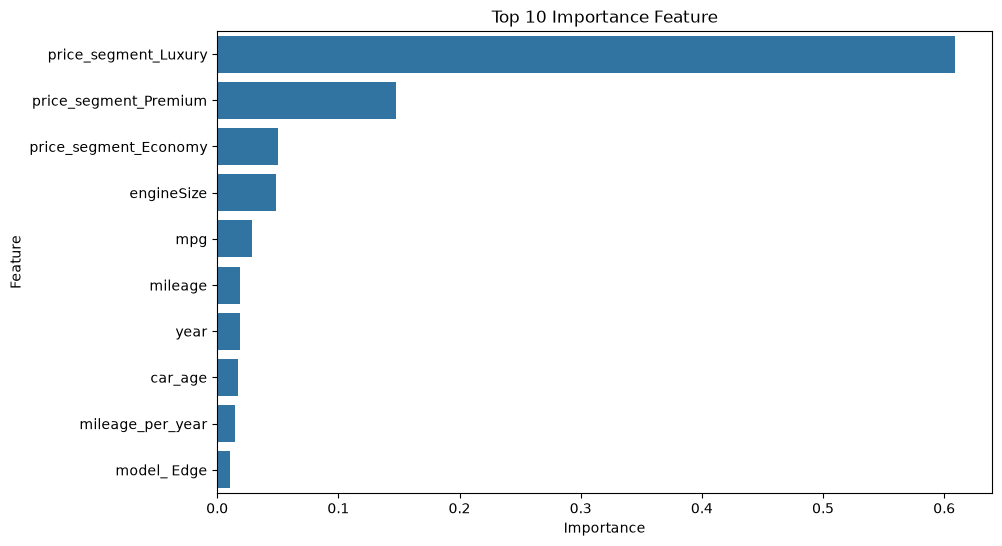

In [68]:
plt.figure(figsize=(10,6))

sns.barplot(
    data = importance.head(10),
    x = "Importance",
    y = "Feature"
)

plt.title("Top 10 Importance Feature")

plt.show()

In [70]:
mi = mutual_info_regression(
    X_encoded,
    y,
    random_state = 42
)

In [73]:
mi_scores = pd.DataFrame({
    "Feature":X_encoded.columns,
    "MI Score": mi
})

mi_scores = mi_scores.sort_values(
    by="MI Score",
    ascending = False
)

mi_scores.head(10)

,Feature,MI Score
42,price_segment_Economy,0.568459
44,price_segment_Premium,0.563529
43,price_segment_Luxury,0.556073
3,mpg,0.524141
0,year,0.506117
5,car_age,0.500518
4,engineSize,0.361004
1,mileage,0.291338
2,tax,0.282788
6,mileage_per_year,0.184898


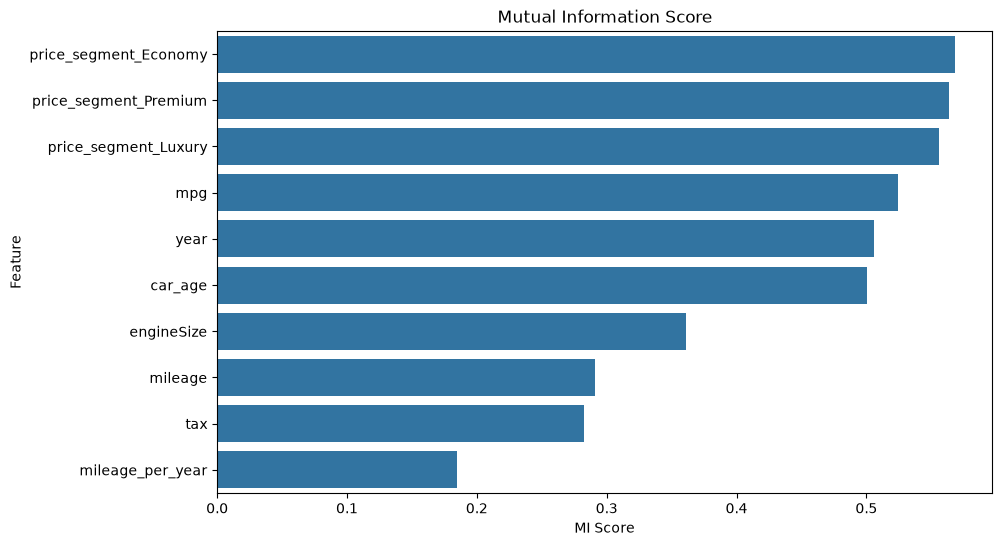

In [76]:
plt.figure(figsize=(10,6))

sns.barplot(
    data= mi_scores.head(10),
    x="MI Score",
    y="Feature"
)

plt.title("Mutual Information Score")

plt.show()

In [77]:
corr = correlation_matrix.abs()

corr

,year,price,mileage,tax,mpg,engineSize,car_age,mileage_per_year
year,1.000000,0.636009,0.707818,0.298506,0.022967,0.137311,1.000000,0.532528
price,0.636009,1.000000,0.530659,0.406857,0.346419,0.411178,0.636009,0.461095
mileage,0.707818,0.530659,1.000000,0.260451,0.120075,0.215035,0.707818,0.952875
tax,0.298506,0.406857,0.260451,1.000000,0.502980,0.184363,0.298506,0.266141
mpg,0.022967,0.346419,0.120075,0.502980,1.000000,0.260521,0.022967,0.183514
engineSize,0.137311,0.411178,0.215035,0.184363,0.260521,1.000000,0.137311,0.210470
car_age,1.000000,0.636009,0.707818,0.298506,0.022967,0.137311,1.000000,0.532528
mileage_per_year,0.532528,0.461095,0.952875,0.266141,0.183514,0.210470,0.532528,1.000000


## Feature Validation Observations

- Car Age has a stronger relationship with price than Year.
- Mileage Per Year appears to be a useful engineered feature.
- Engine Size remains an important predictor.
- Some engineered features contribute little and may be removed later.